# GERDA (rune.fdb) TEM Sounding - Load, Plot, Invert

Reads one TEM sounding out of a GERDA-schema Firebird export (`rune.fdb`),
plots the raw decay curve with `pytem.survey.Survey`, then inverts it for a
1-D layered resistivity model.

Requires the `fdb` package -- run this notebook with an interpreter that has
it installed (e.g. a WinPython env with `fdb` + `scipy`/`numba`), not
necessarily the same environment used for the rest of pyTEM.


In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import gerda_io
from pytem.survey import Survey
from pytem import inversion, plotter
from pytem.inversion import invert
from pytem.plotter import plot_inversion, plot_model

import importlib
importlib.reload(gerda_io)  # pick up gerda_io.py edits without a kernel restart
importlib.reload(inversion)  # pick up inversion.py edits without a kernel restart
importlib.reload(plotter)  # pick up plotter.py edits without a kernel restart
from pytem.inversion import invert
from pytem.plotter import plot_inversion, plot_model


### Parallel / HPC backend switch

One place to flip when moving this notebook to a different machine (e.g. a
shared supercomputer node where it isn't known in advance whether there will
be more CPU cores or a GPU available) -- everything that supports batch
inversion below (`gerda_io.invert_soundings`) reads these two variables.


In [3]:
import os

# 'cpu'    -- N_JOBS worker *processes* (multiprocessing), no GPU
# 'gpu'    -- single process, CUDA backend, soundings run one after another
#             (one physical GPU is one device -- N_JOBS is ignored)
# 'serial' -- single process, no multiprocessing (debugging only)
PARALLEL_BACKEND = "cpu"
N_JOBS = max(1, (os.cpu_count() or 1) - 1)  # used only when PARALLEL_BACKEND == "cpu"

print(f"PARALLEL_BACKEND={PARALLEL_BACKEND!r}, N_JOBS={N_JOBS}, detected CPUs={os.cpu_count()}")


PARALLEL_BACKEND='cpu', N_JOBS=11, detected CPUs=12


In [4]:
import sys, time
import numba
print("executable:", sys.executable)
print("numba:", numba.__version__, "DISABLE_JIT:", numba.config.DISABLE_JIT,
      "THREADING_LAYER:", numba.config.THREADING_LAYER)

from pytem.forward import fwd_square_central
t0 = time.perf_counter()
fwd_square_central(np.full(14, 5.0), np.full(15, 30.0), 16.8,
                   np.geomspace(1e-5, 1e-3, 24), use_cuda=False)
print(f"first call (JIT warmup): {time.perf_counter() - t0:.2f} s")
t0 = time.perf_counter()
fwd_square_central(np.full(14, 5.0), np.full(15, 30.0), 16.8,
                   np.geomspace(1e-5, 1e-3, 24), use_cuda=False)
print(f"second call (warm): {time.perf_counter() - t0:.2f} s")


executable: c:\WPy64-31180\python-3.11.8.amd64\python.exe
numba: 0.65.0 DISABLE_JIT: 0 THREADING_LAYER: default
first call (JIT warmup): 2.24 s
second call (warm): 1.69 s


In [103]:
from pytem.forward import fwd_circle_central

for label, kw in [("square use_numba=True", dict(use_numba=True, use_cuda=False)),
                   ("square use_numba=False", dict(use_numba=False, use_cuda=False))]:
    t0 = time.perf_counter()
    fwd_square_central(np.full(14, 5.0), np.full(15, 30.0), 16.8,
                       np.geomspace(1e-5, 1e-3, 24), **kw)
    print(f"{label}: {time.perf_counter() - t0:.3f} s")

t0 = time.perf_counter()
fwd_circle_central(np.full(14, 5.0), np.full(15, 30.0), 16.8 / np.sqrt(np.pi),
                   np.geomspace(1e-5, 1e-3, 24), use_numba=True, use_cuda=False)
print(f"circle use_numba=True: {time.perf_counter() - t0:.3f} s")


square use_numba=True: 1.925 s
square use_numba=False: 7.578 s
circle use_numba=True: 0.100 s


## 1. Load data

List a few TEM datasets in the database, then read one sounding. Each
sounding may hold more than one "moment" (e.g. dual-moment SkyTEM/tTEM); the
GERDA reader splits repeat-stack segments from the timing/waveform template
segment automatically (see `pytem/gerda_io.py`).


In [5]:
FDB_PATH = r"c:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Skrivebord\rune.fdb"

import fdb as _fdb
_con = _fdb.connect(dsn="localhost:" + FDB_PATH, user="sysdba", password="masterkey", charset="UTF8")
_cur = _con.cursor()
_cur.execute("SELECT COUNT(*), COUNT(DISTINCT PROJECT) FROM DATASET WHERE DATATYPE = 'tem'")
_n_total, _n_projects = _cur.fetchone()
_con.close()
print(f"Total TEM soundings in database: {_n_total} (across {_n_projects} project(s))")

datasets = gerda_io.list_datasets(FDB_PATH, datatype="tem", limit=20)
datasets


Total TEM soundings in database: 4238 (across 1 project(s))


,DATASET,IDENT,PROJECT,NAME,TEMSUBTYPE,POSITION,XUTM,YUTM,ELEVATION,NUMPOS
0,228353,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110201_0116_01,SKYTEM1,1,562458.51880,6.317801e+06,5.0,1
1,228354,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110209_0116_02,SKYTEM1,1,562427.38392,6.317808e+06,5.0,1
2,228355,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110215_0117_01,SKYTEM1,1,562400.06804,6.317812e+06,5.0,1
3,228356,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110223_0117_02,SKYTEM1,1,562359.18723,6.317817e+06,5.0,1
4,228357,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110230_0118_01,SKYTEM1,1,562321.81241,6.317822e+06,5.0,1
5,228358,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110238_0118_02,SKYTEM1,1,562276.26261,6.317829e+06,5.0,1
6,228359,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110244_0119_01,SKYTEM1,1,562240.90478,6.317833e+06,5.0,1
7,228360,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110252_0119_02,SKYTEM1,1,562194.52900,6.317839e+06,5.0,1
8,228361,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110259_0120_01,SKYTEM1,1,562152.72320,6.317844e+06,5.0,1
9,228362,dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122...,dk.nja.grundvand-OSD19og20-SKYTEM,20050122_110307_0120_02,SKYTEM1,1,562106.18542,6.317850e+06,5.0,1


In [6]:
DATASET_INDEX = 10   # try a different sounding from the listing above if the fit looks bad
DATASET_ID = int(datasets["DATASET"].iloc[DATASET_INDEX])
POSITION = 1

sounding = gerda_io.read_sounding(FDB_PATH, dataset_id=DATASET_ID, position=POSITION)

print(f"Sounding {sounding.dataset_id} ({sounding.ident})")
print(f"  x={sounding.x:.1f}, y={sounding.y:.1f}, elevation={sounding.elevation:.1f} m")
print(f"  moments: {list(sounding.moments)}")
for label, m in sounding.moments.items():
    print(f"  {label}: {len(m['times'])} gates, {m['n_segments']} stacked segments, "
          f"geometry={m['geometry']}, tx_size={m['tx_size']:.1f} m")


Sounding 228363 (dk.nja.grundvand-OSD19og20-SKYTEM.tem.20050122_110313_0121_01)
  x=562076.0, y=6317856.5, elevation=5.0 m
  moments: ['M1']
  M1: 26 gates, 4 stacked segments, geometry=square_central, tx_size=16.8 m


## 2. Plot raw data

Wrap the sounding in `gerda_io.GerdaTEMAdapter` so `pytem.survey.Survey` (built
for TEM Data Manager `.xyz` files) can be reused as-is: each moment's repeat
segments stand in for the repeat station records `Survey` normally plots.


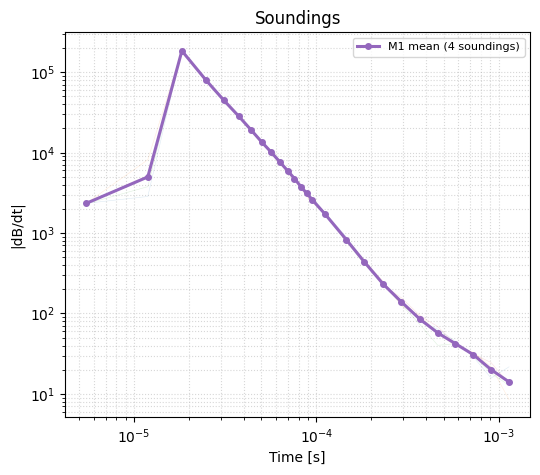

In [7]:
adapter = gerda_io.GerdaTEMAdapter(sounding)
surv = Survey(adapter)

# Survey.moments defaults to ('LM', 'HM'); GERDA moments are labelled
# 'M1', 'M2', ... so pass them explicitly.
moment_labels = list(sounding.moments)

fig, ax = plt.subplots(figsize=(6, 5))
surv.plot_soundings(moments=moment_labels, ax=ax)
plt.show()


## 2b. Plot signal vs. distance along the profile

A single sounding has no "distance" axis, so pull every dataset from the
same `PROJECT` as the reference sounding (typically one flight line/profile)
and wrap them in `gerda_io.GerdaLineAdapter`, which reuses the same
`_PositionMixin` (line grouping, UTM distance) as the `.xyz` readers.


Project 'dk.nja.grundvand-OSD19og20-SKYTEM': reading 40 of its datasets
Usable soundings for the 'M1' transect: 21


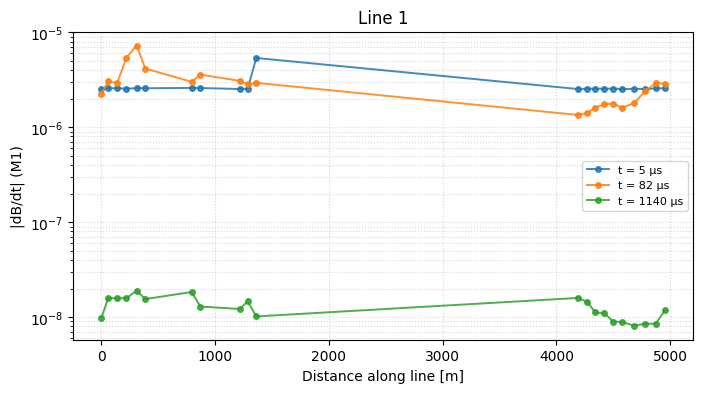

In [8]:
N_LINE_SOUNDINGS = 40  # a project can span the whole survey (thousands of
                        # stations); cap how many get read for the transect plot

project = datasets.loc[datasets["DATASET"] == DATASET_ID, "PROJECT"].iloc[0]
project_datasets = gerda_io.list_datasets(FDB_PATH, datatype="tem", project=project,
                                          limit=N_LINE_SOUNDINGS)
print(f"Project {project!r}: reading {len(project_datasets)} of its datasets")

LINE_MOMENT = moment_labels[0]   # moment shared across the profile's soundings
line_soundings = gerda_io.read_soundings(
    FDB_PATH, project_datasets["DATASET"].tolist(), position=1)

# Keep only soundings that have the chosen moment with the same gate count
# as the reference sounding (a profile can mix a few different system setups).
n_gates_ref = len(sounding.moments[LINE_MOMENT]["times"])
line_soundings = [
    s for s in line_soundings
    if LINE_MOMENT in s.moments and len(s.moments[LINE_MOMENT]["times"]) == n_gates_ref
]
print(f"Usable soundings for the '{LINE_MOMENT}' transect: {len(line_soundings)}")

line_adapter = gerda_io.GerdaLineAdapter(line_soundings, moment=LINE_MOMENT)
line_surv = Survey(line_adapter)

fig, ax = plt.subplots(figsize=(8, 4))
line_surv.plot_transects(LINE_MOMENT, axes=np.array([ax]), x_axis="distance")
plt.show()


## 2c. Plot survey map

Station positions for the same project, coloured by line (falls back to a
plain scatter if `contextily`/the basemap tile server is unavailable).


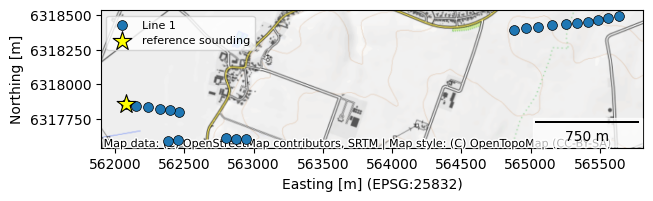

In [109]:
fig, ax = plt.subplots(figsize=(7, 7))
line_surv.plot_map(ax=ax)
ax.scatter(sounding.x, sounding.y, marker="*", s=200, c="yellow",
          edgecolors="k", linewidths=0.8, zorder=6, label="reference sounding")
ax.legend(fontsize=8, loc="upper left", framealpha=0.8)
plt.show()


## 3. Invert the reference sounding

Fit a smooth layered model to the first moment with `pytem.inversion.invert`.
`gerda_io.invert_kwargs()` builds the keyword arguments from the moment dict,
converting the fractional per-gate noise to the absolute values `invert`
expects for an array `noise_std`.


In [11]:
INVERT_MOMENT = moment_labels[0]
m = sounding.moments[INVERT_MOMENT]

# The first two gates rise then fall instead of decaying monotonically
# (see section 2 sounding plot) -- exclude them from the fit.
N_DROP_EARLY_GATES = 2
m_fit = dict(m)
for key in ("times", "obs_data", "noise_std"):
    m_fit[key] = m[key][N_DROP_EARLY_GATES:]

N_LAYERS = 18
#N_LAYERS = 14
# A single fixed growth factor (industry-standard, e.g. Aarhus Workbench-style
# layering) instead of log-spacing directly between a min/max thickness: the
# latter forces a big jump at the bottom (2->40 m over just 9 layers, factor
# ~1.46x per layer) to reach depth; a gentler ~1.15x factor with more layers
# reaches the same depth without any single layer dominating.
FIRST_THICKNESS = 2.0
GROWTH_FACTOR = 1.15
#GROWTH_FACTOR = 1.25
thicknesses = FIRST_THICKNESS * GROWTH_FACTOR ** np.arange(N_LAYERS - 1)
print(f"Depth reached: {thicknesses.sum():.1f} m over {N_LAYERS - 1} layers "
      f"(thickest layer: {thicknesses[-1]:.1f} m)")
# Start from the data's own apparent resistivity rather than a fixed guess --
# a uniform 50 Ohm.m start was ~8x off for some soundings, which alone can
# stall the Gauss-Newton search far from the true model.
from pytem.inversion import dbdt_to_apprho
tx_area_moment = m_fit["tx_size"] ** 2 * m_fit["peak_current"] * m_fit["tx_turns"]
app_rho = dbdt_to_apprho(m_fit["obs_data"], tx_area_moment, m_fit["times"])
rho_start = float(np.nanmedian(app_rho[np.isfinite(app_rho) & (app_rho > 0)]))
log_resistivities = np.full(N_LAYERS, np.log(rho_start))
print(f"Starting model: uniform {rho_start:.1f} Ohm.m (median apparent resistivity)")

result = invert(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    transform="euler", rho_min=0.1, rho_max=1e5,
    use_cuda=(PARALLEL_BACKEND == "gpu"),  # follows the backend switch above
    # regularization: "l2" (default, smooth Occam-style) or "l1" (blocky,
    # see section 4b) -- explicit here so it's clear which one is running.
    regularization="l1",
    # max_noise_frac defaults to 0.10 (10% of the *peak* |obs|, not each
    # gate's own value); for a decay spanning several orders of magnitude
    # that floor swamps the real per-gate noise for small late-time gates,
    # letting the model be badly wrong there without penalty. Disable it.
    max_noise_frac=0.0, step_backtrack=True,
    **gerda_io.invert_kwargs(m_fit, as_circle=True),
)

print(f"Moment {INVERT_MOMENT}: geometry={m['geometry']!r}, tx_size={m['tx_size']:.2f} m, "
      f"rx=({m['rx_x']:.2f}, {m['rx_y']:.2f}) m, tx_height={m['tx_height']:.1f} m, "
      f"rx_height={m['rx_height']:.1f} m")
print("Inverting with the equal-area equivalent circle (much faster than the "
      "square-loop quadrature; GERDA's own TXSIDE1/TXSIDE2 are already an "
      "equivalent-square stand-in for the real airborne frame, so this is no "
      "less accurate).")
print(f"Fitting {len(m_fit['times'])}/{len(m['times'])} gates "
      f"(dropped first {N_DROP_EARLY_GATES})")
print(f"Converged: {result['n_iter']} iteration(s), final RMS = {result['rms_history'][-1]:.3f}")


Depth reached: 130.2 m over 17 layers (thickest layer: 18.7 m)
Starting model: uniform 68.1 Ohm.m (median apparent resistivity)
[invert] geometry=circle_central, transform=euler, fwd_backend=numba, jac_backend=numba, analytical_j=True, waveform=True
Observed data: Mean Apparent Resistivity = 6.4 Ohm.m (over 24/24 valid gates)
Alpha start = 1295.850
Iteration   1:  RMS = 17.76
    Alpha = 1295.85,  RMS = 5.84
    Alpha = 1003.33,  RMS = 5.98
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 5.84
    Alpha = 1673.65,  RMS = 3.18
    Alpha = 1295.85,  RMS = 2.84
    Alpha = 1003.33,  RMS = 2.58
    Alpha = 776.84,  RMS = 2.41
    Alpha = 601.48,  RMS = 2.33
Iteration   3:  RMS = 2.33
    Alpha = 776.84,  RMS = 2.23
    Alpha = 601.48,  RMS = 2.22
    Alpha = 465.70,  RMS = 2.22
    Alpha = 360.58,  RMS = 2.22
    Alpha = 279.18,  RMS = 2.22
Iteration   4:  RMS = 2.22
    Alpha = 360.58,  RMS = 2.22
    Alpha = 279.18,  RMS = 2.22
    RMS increased - stopping alpha sea

## 4. Show results

Observed vs. modelled decay curve, RMS convergence, and the recovered
resistivity-depth model. `gerda_io.predict_response()` forward-models the
final layer parameters (including the waveform convolution) for the
observed-vs-modelled panel.


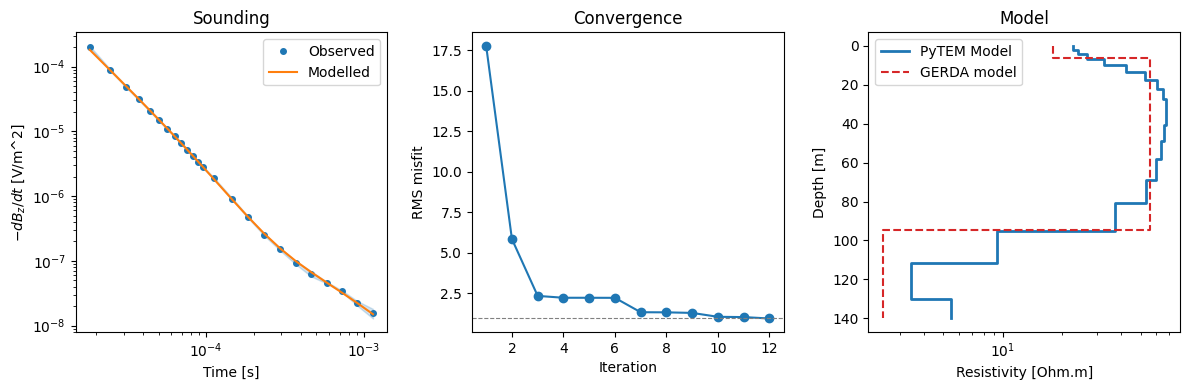

In [139]:
pred = gerda_io.predict_response(result["thicknesses"], result["resistivities"], m_fit,
                                as_circle=True)

# Overlay GERDA's own official em1dinv model for this sounding, if one is
# linked (MODEL/ODVLAYER via ODVMODSE), as a "true model" comparison.
import fdb as _fdb
_con = _fdb.connect(dsn="localhost:" + FDB_PATH, user="sysdba", password="masterkey", charset="UTF8")
_cur = _con.cursor()
_cur.execute("SELECT MODEL FROM ODVMODSE WHERE DATASET = ?", (DATASET_ID,))
_row = _cur.fetchone()
gerda_rho = gerda_thick = None
if _row is not None:
    _cur.execute("SELECT RHO, THICKNESS FROM ODVLAYER WHERE MODEL = ? ORDER BY LAYER", (_row[0],))
    _layers = _cur.fetchall()
    gerda_rho = np.array([r[0] for r in _layers], dtype=float)
    # plot_inversion's true_thicknesses expects one value per layer (it drops
    # the last internally), unlike `thicknesses` (N-1); pad with a dummy.
    gerda_thick = np.append(np.array([r[1] for r in _layers[:-1]], dtype=float), 0.0)
_con.close()

fig, axs = plot_inversion(
    times=m_fit["times"], obs_data=m_fit["obs_data"], mod_data=pred,
    thicknesses=result["thicknesses"], best_rho=result["resistivities"],
    iter_rms_list=result["rms_history"],
    # plot_inversion's `noise` follows the same convention as invert()'s
    # noise_std: an array is absolute, not fractional -- convert here too.
    noise=m_fit["noise_std"] * np.abs(m_fit["obs_data"]),
    true_rho=gerda_rho, true_thicknesses=gerda_thick,
    model_label="PyTEM Model", true_label="GERDA model",
)
plt.show()


## 5. Batch-invert a whole profile (parallel)

Invert several soundings from the same profile at once with
`gerda_io.invert_soundings`, reusing the layering/starting model from
section 3. Controlled entirely by `PARALLEL_BACKEND`/`N_JOBS` set earlier --
change those two variables (e.g. to `"gpu"` on a machine with a GPU) and
rerun this cell, no other changes needed.


In [12]:
N_BATCH_SOUNDINGS = min(20, len(line_soundings))  # keep the demo quick; raise for a real run
batch_soundings = line_soundings[:N_BATCH_SOUNDINGS]

t0 = time.perf_counter()
batch_results = gerda_io.invert_soundings(
    batch_soundings, LINE_MOMENT, thicknesses, log_resistivities,
    n_jobs=N_JOBS, backend=PARALLEL_BACKEND, as_circle=True,
    n_drop_early_gates=N_DROP_EARLY_GATES,
    transform="euler", rho_min=0.1, rho_max=1e5,
    maxit=50,
    regularization="l2", max_noise_frac=0.0, step_backtrack=True,
)
elapsed = time.perf_counter() - t0

n_ok = sum("error" not in r for r in batch_results)
print(f"backend={PARALLEL_BACKEND!r}, n_jobs={N_JOBS}: inverted {n_ok}/{len(batch_results)} "
      f"soundings in {elapsed:.1f} s ({elapsed / len(batch_results):.2f} s/sounding)")


  (20/20) DATASET=228386: RMS=1.306 in 50 iter
backend='cpu', n_jobs=11: inverted 20/20 soundings in 2552.8 s (127.64 s/sounding)


## 6. Plot the batch-inverted profile as stationary soundings

`profiler` already has an option for this: `Plot.addTEMSoundings` draws each
sounding as its own disconnected log (used for ground/"stationary" sTEM,
as opposed to the continuously-interpolated tTEM `plot2D`), which is
exactly right for GERDA stations that can be 100s-1000s of metres apart.
It expects a `Model` populated the same way `loadXYZ(..., model_type='sTEM')`
would, so a minimal `stem_models`/`profiles` entry is built by hand here
from the section 5 batch results instead.


Plotting 20/20 successfully inverted soundings


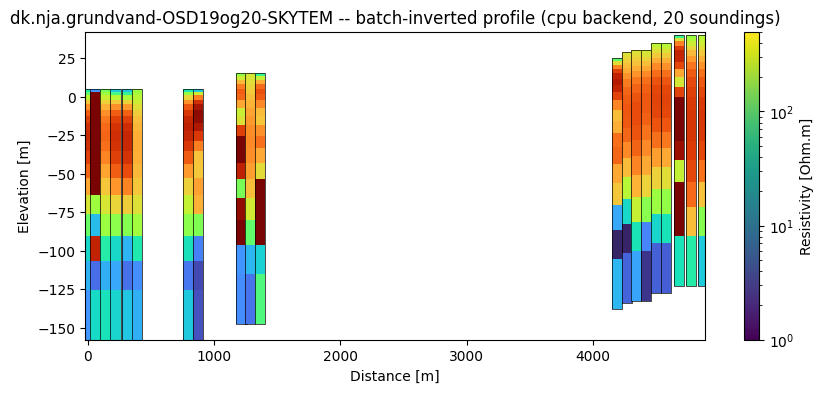

In [13]:
sys.path.insert(0, r"c:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\profiler\src\profiler")
import profiler
importlib.reload(profiler)

ok = [(s, r) for s, r in zip(batch_soundings, batch_results) if "error" not in r]
print(f"Plotting {len(ok)}/{len(batch_results)} successfully inverted soundings")

xy = np.array([(s.x, s.y) for s, _ in ok])
elev = np.array([s.elevation for s, _ in ok])
rhos = np.array([r["resistivities"] for _, r in ok])

# every sounding shares `thicknesses` -> same bottom depth per layer, plus a
# small pad for the open-ended half-space (display only)
LAST_LAYER_PAD = 0.25 * thicknesses.sum()
bots = np.append(thicknesses.cumsum(), thicknesses.sum() + LAST_LAYER_PAD)
# addTEMSoundings only fills the first `n_layers - 1` layers (see profiler.py) --
# append a dummy last layer so every *real* layer (including the half-space)
# gets drawn; doi_con is set beyond the deepest real layer since we have no
# real DOI estimate, so addTEMSoundings never fades a layer out.
depths = np.tile(np.append(bots, bots[-1] + 0.01), (len(ok), 1))
rhos_padded = np.hstack([rhos, rhos[:, -1:]])
doi_con = np.full(len(ok), bots[-1])

pmodel = profiler.Model()
pmodel.stem_models.append({
    "x": xy[:, 0], "y": xy[:, 1], "elev": elev,
    "rhos": rhos_padded, "depths": depths, "doi_con": doi_con,
})
xi, yi, line_dists = pmodel.interpCoords(xy[:, 0], xy[:, 1], distance=10)
pmodel.profiles.append({"x": xy[:, 0], "y": xy[:, 1], "xi": xi, "yi": yi,
                        "distances": line_dists, "elev": elev})

pplot = profiler.Plot(pmodel)
fig, ax = plt.subplots(figsize=(10, 4))
vmin, vmax = 1, 500
pplot.addTEMSoundings(profile_idx=0, stem_model_idx=0, ax=ax, vmin=vmin, vmax=vmax,
                     log=True, cmap=plt.cm.turbo, search_radius=50)

dists = np.concatenate([[0.0], np.cumsum(np.hypot(*np.diff(xy, axis=0).T))])
ax.set_xlim(dists.min() - 20, dists.max() + 20)
ax.set_ylim((elev - bots[-1]).min(), elev.max() + 2)
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")

from matplotlib.colors import LogNorm
sm = plt.cm.ScalarMappable(norm=LogNorm(vmin=vmin, vmax=vmax), cmap=plt.cm.viridis)
fig.colorbar(sm, ax=ax, label="Resistivity [Ohm.m]")
ax.set_title(f"{project} -- batch-inverted profile ({PARALLEL_BACKEND} backend, {len(ok)} soundings)")
plt.show()

## 7. Spatial smoothing along the profile

Independent per-sounding inversion (section 5) has no lateral constraint --
neighbouring stations can jump around even where the true geology is smooth,
since noise in one sounding can't "borrow strength" from its neighbours. A
fast, standard fix (airborne EM processing does this routinely) is
**Gaussian-kernel smoothing along the profile in log-resistivity space**,
corrected for topography: each neighbour's resistivity-vs-elevation profile
is first *resampled onto the target's own elevation* (piecewise-linear
interpolation in log-rho vs. elevation), then those elevation-matched values
are kriged together with a horizontal-distance-only Gaussian kernel.

A naive 2-D (distance, elevation) kernel comparing every layer of a
neighbour against the target layer looks appealing but has a subtle flaw:
a neighbour then contributes up to `n_layers` separate weighted points
against the target's single self-point, so one nearby station can
out-weigh the sounding's *own* well-constrained value entirely. Resampling
first collapses each neighbour to exactly one comparable value per target
layer (matched by true elevation, not layer index), so self and neighbours
compete on equal footing and only horizontal distance sets the weight.

After smoothing, each station's data misfit is recomputed against its *own*
observed data using the *smoothed* model (`gerda_io.predict_response` +
the same weighted-log-RMS formula `invert()` uses internally) -- this is the
"ensure not changing much" check: a station whose RMS blows up after
smoothing likely has a real lateral change nearby (e.g. a fault) that
smoothing has wrongly suppressed, and is worth a closer look rather than
trusting the smoothed model.

**Bandwidth matters a lot here**: a sweep of this dataset showed that even
immediate neighbours (60-400 m apart) can independently invert to
resistivity values differing by 5-6x for the *same* shallow layer (classic
TEM resistivity/thickness equivalence -- each fit is individually valid for
its own noisy data, but they aren't laterally consistent). A plain Gaussian
kernel wide enough to actually smooth anything therefore also lets those
outlier neighbours wreck the fit. The fix is **robust reweighting** (IRLS
with a Tukey biweight): after an initial Gaussian-weighted estimate, any
neighbour whose value disagrees strongly with the running estimate gets
down-weighted before the next pass -- so a wider, more useful bandwidth can

be used while still automatically ignoring the 5-6x equivalence outliers.

In [31]:
log_rhos = np.log(rhos)  # (n_soundings, n_layers), from section 6
n_soundings, n_layers = log_rhos.shape

# Depth of each layer's midpoint (shared by every station -- only true
# elevation differs, via each station's own ground elevation).
bottoms_finite = thicknesses.cumsum()                      # (n_layers-1,)
tops_finite = np.concatenate(([0.0], bottoms_finite[:-1]))
mids_finite = (tops_finite + bottoms_finite) / 2.0
# half-space has no real bottom -- extrapolate one more layer thickness,
# same convention as pytem.inversion.getAlphas()
half_space_mid = bottoms_finite[-1] + thicknesses[-1] / 2.0
layer_mid_depths = np.append(mids_finite, half_space_mid)  # (n_layers,)

# True elevation of every (station, layer) midpoint
elev_mid = elev[:, None] - layer_mid_depths[None, :]        # (n_soundings, n_layers)

SMOOTH_BANDWIDTH = 1.0 * np.median(np.diff(np.sort(dists)))  # wider -- robust reweighting protects it
ROBUST_TUNING = 4.685  # standard Tukey biweight constant (in robust-sigma units)
N_IRLS_ITERS = 3
W_station = np.exp(-0.5 * ((dists[:, None] - dists[None, :]) / SMOOTH_BANDWIDTH) ** 2)


def _biweight(u):
    w = np.zeros_like(u)
    inside = np.abs(u) < 1
    w[inside] = (1 - u[inside] ** 2) ** 2
    return w


# For each target (station i, layer j), resample every *other* station's own
# profile onto the target's true elevation first (so each neighbour
# contributes exactly one comparable value, matched by elevation not layer
# index) -- then smooth horizontally, iteratively down-weighting whichever
# neighbour(s) disagree most with the running estimate (IRLS). elev_mid
# decreases with depth, so reverse to the ascending order np.interp requires.
smoothed_log_rhos = np.empty_like(log_rhos)
for i in range(n_soundings):
    w0 = W_station[i]
    for j in range(n_layers):
        z_target = elev_mid[i, j]
        vals = np.array([np.interp(z_target, elev_mid[k, ::-1], log_rhos[k, ::-1])
                         for k in range(n_soundings)])
        w = w0.copy()
        est = np.sum(w * vals) / np.sum(w)
        for _ in range(N_IRLS_ITERS):
            resid = vals - est
            scale = 1.4826 * np.median(np.abs(resid)) + 1e-6  # robust (MAD) sigma
            w = w0 * _biweight(resid / (ROBUST_TUNING * scale))
            if w.sum() < 1e-8:
                break
            est = np.sum(w * vals) / np.sum(w)
        smoothed_log_rhos[i, j] = est

smoothed_rhos = np.exp(smoothed_log_rhos)
print(f"Smoothing bandwidth: {SMOOTH_BANDWIDTH:.1f} m horizontal "
      f"(median station spacing: {np.median(np.diff(np.sort(dists))):.1f} m)")


def weighted_log_rms(obs_data, mod_data, noise_std):
    # matches invert()'s own RMS convention exactly: w = obs/noise_abs = 1/noise_std
    # (noise_std here is fractional, as stored in the moment dict)
    valid = (obs_data > 0) & (mod_data > 0)
    w = 1.0 / noise_std[valid]
    res_log = np.log(obs_data[valid]) - np.log(mod_data[valid])
    return np.sqrt(np.mean((w * res_log) ** 2))


print(f"{'DATASET':>8}  {'RMS orig':>9}  {'RMS smooth':>10}  {'change':>8}")
rms_orig, rms_smooth = [], []
for i, (s, r) in enumerate(ok):
    m = dict(s.moments[LINE_MOMENT])
    for key in ("times", "obs_data", "noise_std"):
        m[key] = m[key][N_DROP_EARLY_GATES:]
    pred_smooth = gerda_io.predict_response(thicknesses, smoothed_rhos[i], m, as_circle=True)
    r_orig = r["rms_history"][-1]
    r_smooth = weighted_log_rms(m["obs_data"], pred_smooth, m["noise_std"])
    rms_orig.append(r_orig)
    rms_smooth.append(r_smooth)
    flag = "  <-- degraded" if r_smooth > max(1.5 * r_orig, r_orig + 0.5) else ""
    print(f"{s.dataset_id:>8}  {r_orig:>9.3f}  {r_smooth:>10.3f}  "
          f"{r_smooth - r_orig:>+8.3f}{flag}")

rms_orig, rms_smooth = np.array(rms_orig), np.array(rms_smooth)
print(f"\nMedian RMS: {np.median(rms_orig):.3f} -> {np.median(rms_smooth):.3f} after smoothing "
      f"(bandwidth={SMOOTH_BANDWIDTH:.0f} m -- raise/lower it and rerun to trade off "
      f"smoothness vs. fit)")

Smoothing bandwidth: 78.9 m horizontal (median station spacing: 78.9 m)
 DATASET   RMS orig  RMS smooth    change
  228353      2.096      14.778   +12.682  <-- degraded
  228355      2.523      11.463    +8.940  <-- degraded
  228357      0.637       4.900    +4.263  <-- degraded
  228359      1.097       8.596    +7.500  <-- degraded
  228361      1.099       9.566    +8.467  <-- degraded


KeyboardInterrupt: 

In [ ]:
# TEMP DEBUG: fast (no forward-modelling) sweep of bandwidth for the robust smoother
def robust_smooth(bw):
    Wt = np.exp(-0.5 * ((dists[:, None] - dists[None, :]) / bw) ** 2)
    slr = np.empty_like(log_rhos)
    for ii in range(n_soundings):
        w0_ = Wt[ii]
        for jj in range(n_layers):
            z_t_ = elev_mid[ii, jj]
            vals_ = np.array([np.interp(z_t_, elev_mid[kk, ::-1], log_rhos[kk, ::-1])
                              for kk in range(n_soundings)])
            w_ = w0_.copy()
            est_ = np.sum(w_ * vals_) / np.sum(w_)
            for _ in range(N_IRLS_ITERS):
                resid_ = vals_ - est_
                scale_ = 1.4826 * np.median(np.abs(resid_)) + 1e-6
                w_ = w0_ * _biweight(resid_ / (ROBUST_TUNING * scale_))
                if w_.sum() < 1e-8:
                    break
                est_ = np.sum(w_ * vals_) / np.sum(w_)
            slr[ii, jj] = est_
    return slr

spacing = np.median(np.diff(np.sort(dists)))
for bw_factor in [0.15, 0.25, 0.35, 0.5, 0.75, 1.0]:
    bw = bw_factor * spacing
    slr = robust_smooth(bw)
    log_change = np.abs(slr - log_rhos)
    print(f"bw={bw:6.1f} m ({bw_factor:.2f}x spacing): median |log change|={np.median(log_change):.3f}, "
          f"max |log change|={np.max(log_change):.3f} (factor {np.exp(np.max(log_change)):.1f}x)")

### 7b. Plot the smoothed profile

Same `addTEMSoundings` rendering as section 6, fed `smoothed_rhos` instead
of the independent per-station `rhos`, for a direct visual comparison.


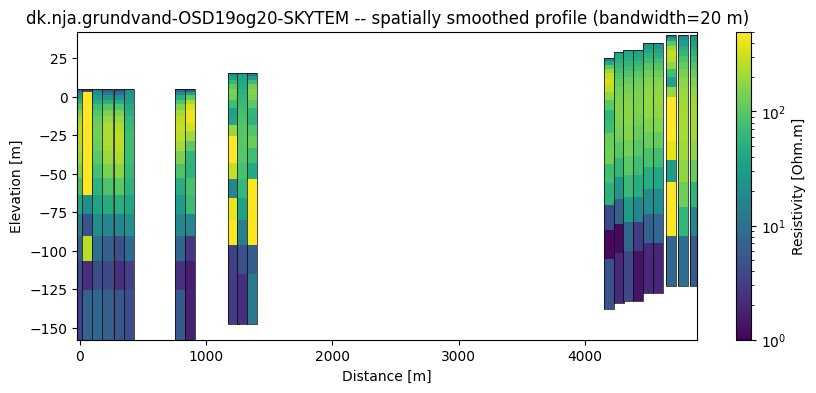

In [29]:
smoothed_rhos_padded = np.hstack([smoothed_rhos, smoothed_rhos[:, -1:]])

pmodel_smooth = profiler.Model()
pmodel_smooth.stem_models.append({
    "x": xy[:, 0], "y": xy[:, 1], "elev": elev,
    "rhos": smoothed_rhos_padded, "depths": depths, "doi_con": doi_con,
})
pmodel_smooth.profiles.append({"x": xy[:, 0], "y": xy[:, 1], "xi": xi, "yi": yi,
                               "distances": line_dists, "elev": elev})

pplot_smooth = profiler.Plot(pmodel_smooth)
fig, ax = plt.subplots(figsize=(10, 4))
pplot_smooth.addTEMSoundings(profile_idx=0, stem_model_idx=0, ax=ax, vmin=vmin, vmax=vmax,
                             log=True, cmap=plt.cm.viridis, search_radius=50)

ax.set_xlim(dists.min() - 20, dists.max() + 20)
ax.set_ylim((elev - bots[-1]).min(), elev.max() + 2)
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")
fig.colorbar(sm, ax=ax, label="Resistivity [Ohm.m]")
ax.set_title(f"{project} -- spatially smoothed profile (bandwidth={SMOOTH_BANDWIDTH:.0f} m)")
plt.show()

## 8. Laterally-constrained inversion (LCI), warm-started from section 5

Post-hoc smoothing (section 7) can only ever *average* independent models
that are already stuck wherever their own Gauss-Newton search landed --
section 7 showed that's not good enough here, since immediate neighbours
can independently converge to resistivities differing 5-6x for the same
layer (TEM's classic resistivity/thickness equivalence). The proper fix is
to invert every station *jointly*: one combined Gauss-Newton solve over all
stations at once, adding a **lateral roughness** penalty (station `i`
layer `j` vs. station `i+1` layer `j`, inverse-distance weighted so far-apart
stations -- e.g. across the profile's data gap -- are barely tied) on top of
each station's own ordinary vertical roughness. This lets the *data itself*
push back against an over-strong lateral tie, station by station, instead of
blindly averaging.

Warm-starting `m` from the section 5 independent inversions (rather than a
flat starting model) means only a handful of further Gauss-Newton
iterations are needed. The Jacobian here is finite-difference (`n_layers+1`
forward calls per station per iteration = ~19x20=380 calls/iteration) rather
than pytem's analytical one, since `getJ_ana` doesn't expose the waveform
convolution chain rule as a standalone function -- simpler and still fast
enough for a handful of warm-started iterations, but expect a few minutes
per iteration.


In [32]:
N_LCI_ITER = 4
ALPHA_VERTICAL_FRAC = 0.3   # vertical roughness strength, as a fraction of the auto data-gradient scale
ALPHA_LATERAL_FRAC = 1.0    # lateral roughness strength, same units -- the main "how much to trust neighbours" knob
FD_EPS = 1e-4

from pytem.inversion import getR

lci_moments = []
for s, r in ok:
    mi = dict(s.moments[LINE_MOMENT])
    for key in ("times", "obs_data", "noise_std"):
        mi[key] = mi[key][N_DROP_EARLY_GATES:]
    lci_moments.append(mi)

n_tot = n_soundings * n_layers


def station_forward(i, m_i):
    return gerda_io.predict_response(thicknesses, np.exp(m_i), lci_moments[i],
                                     as_circle=True, transform="euler")


def station_jacobian(i, m_i, d0):
    J = np.zeros((len(d0), n_layers))
    for j in range(n_layers):
        m_pert = m_i.copy()
        m_pert[j] += FD_EPS
        d1 = station_forward(i, m_pert)
        J[:, j] = (np.log(d1) - np.log(d0)) / FD_EPS
    return J


# Vertical roughness: same per-station block every time (getR only depends
# on parameter count when weights=None), tiled block-diagonal across stations.
Rv_block = getR(np.ones(n_layers), damp=1e-4)
Rv = np.zeros((n_tot, n_tot))
for i in range(n_soundings):
    sl = slice(i * n_layers, (i + 1) * n_layers)
    Rv[sl, sl] = Rv_block

# Lateral roughness: only CONSECUTIVE stations in profile order, inverse-distance
# weighted (so the ~2.6 km data gap barely ties the stations either side of it).
Dl_rows, Dl_w = [], []
for i in range(n_soundings - 1):
    gap = max(dists[i + 1] - dists[i], 1.0)
    w_pair = 1.0 / gap
    for j in range(n_layers):
        row = np.zeros(n_tot)
        row[i * n_layers + j] = -1.0
        row[(i + 1) * n_layers + j] = 1.0
        Dl_rows.append(row)
        Dl_w.append(w_pair)
Dl = np.array(Dl_rows)
Wl = np.array(Dl_w)
Wl /= np.median(Wl)  # normalise so ALPHA_LATERAL_FRAC has a consistent meaning
Rl = Dl.T @ np.diag(Wl) @ Dl

m = log_rhos.copy()  # warm start from the section 5 independent inversions
alpha_v = alpha_l = None
for it in range(N_LCI_ITER):
    t_iter = time.perf_counter()
    preds, Js = [], []
    for i in range(n_soundings):
        d0 = station_forward(i, m[i])
        preds.append(d0)
        Js.append(station_jacobian(i, m[i], d0))

    dw_parts, row_sizes = [], []
    for i in range(n_soundings):
        obs = lci_moments[i]["obs_data"]
        w_i = 1.0 / lci_moments[i]["noise_std"]
        dw_parts.append(w_i * (np.log(obs) - np.log(preds[i])))
        row_sizes.append(len(obs))
    dw = np.concatenate(dw_parts)

    Jw = np.zeros((len(dw), n_tot))
    row0 = 0
    for i in range(n_soundings):
        n_g = row_sizes[i]
        w_i = 1.0 / lci_moments[i]["noise_std"]
        Jw[row0:row0 + n_g, i * n_layers:(i + 1) * n_layers] = w_i[:, None] * Js[i]
        row0 += n_g

    if alpha_v is None:
        alpha_auto = float(np.linalg.norm(Jw.T @ dw, np.inf) + 1e-30)
        alpha_v = ALPHA_VERTICAL_FRAC * alpha_auto
        alpha_l = ALPHA_LATERAL_FRAC * alpha_auto

    R = alpha_v * Rv + alpha_l * Rl
    m_flat = m.flatten()
    lhs = Jw.T @ Jw + R
    rhs = Jw.T @ dw - R @ m_flat
    dm, *_ = np.linalg.lstsq(lhs, rhs, rcond=1e-10)
    m_flat = np.clip(m_flat + dm, np.log(0.1), np.log(1e5))
    m = m_flat.reshape(n_soundings, n_layers)

    joint_rms = np.sqrt(np.mean(dw ** 2))
    print(f"iter {it + 1}/{N_LCI_ITER}: joint weighted RMS = {joint_rms:.3f} "
          f"({time.perf_counter() - t_iter:.0f} s)")

lci_rhos = np.exp(m)

iter 1/4: joint weighted RMS = 1.279 (7292 s)
iter 2/4: joint weighted RMS = 6.433 (1396 s)
iter 3/4: joint weighted RMS = 2.916 (657 s)
iter 4/4: joint weighted RMS = 2.398 (1326 s)


In [ ]:
print(f"{'DATASET':>8}  {'RMS orig':>9}  {'RMS LCI':>9}  {'change':>8}")
rms_lci = []
for i, (s, r) in enumerate(ok):
    pred_lci = gerda_io.predict_response(thicknesses, lci_rhos[i], lci_moments[i],
                                         as_circle=True, transform="euler")
    r_orig = r["rms_history"][-1]
    r_lci = weighted_log_rms(lci_moments[i]["obs_data"], pred_lci, lci_moments[i]["noise_std"])
    rms_lci.append(r_lci)
    flag = "  <-- degraded" if r_lci > max(1.5 * r_orig, r_orig + 0.5) else ""
    print(f"{s.dataset_id:>8}  {r_orig:>9.3f}  {r_lci:>9.3f}  {r_lci - r_orig:>+8.3f}{flag}")

rms_lci = np.array(rms_lci)
print(f"\nMedian RMS: {np.median(rms_orig):.3f} -> {np.median(rms_lci):.3f} after LCI "
      f"(alpha_vertical={alpha_v:.1f}, alpha_lateral={alpha_l:.1f})")

lci_rhos_padded = np.hstack([lci_rhos, lci_rhos[:, -1:]])
pmodel_lci = profiler.Model()
pmodel_lci.stem_models.append({
    "x": xy[:, 0], "y": xy[:, 1], "elev": elev,
    "rhos": lci_rhos_padded, "depths": depths, "doi_con": doi_con,
})
pmodel_lci.profiles.append({"x": xy[:, 0], "y": xy[:, 1], "xi": xi, "yi": yi,
                            "distances": line_dists, "elev": elev})

pplot_lci = profiler.Plot(pmodel_lci)
fig, ax = plt.subplots(figsize=(10, 4))
pplot_lci.addTEMSoundings(profile_idx=0, stem_model_idx=0, ax=ax, vmin=vmin, vmax=vmax,
                          log=True, cmap=plt.cm.viridis, search_radius=50)
ax.set_xlim(dists.min() - 20, dists.max() + 20)
ax.set_ylim((elev - bots[-1]).min(), elev.max() + 2)
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")
fig.colorbar(sm, ax=ax, label="Resistivity [Ohm.m]")
ax.set_title(f"{project} -- laterally-constrained inversion result")
plt.show()